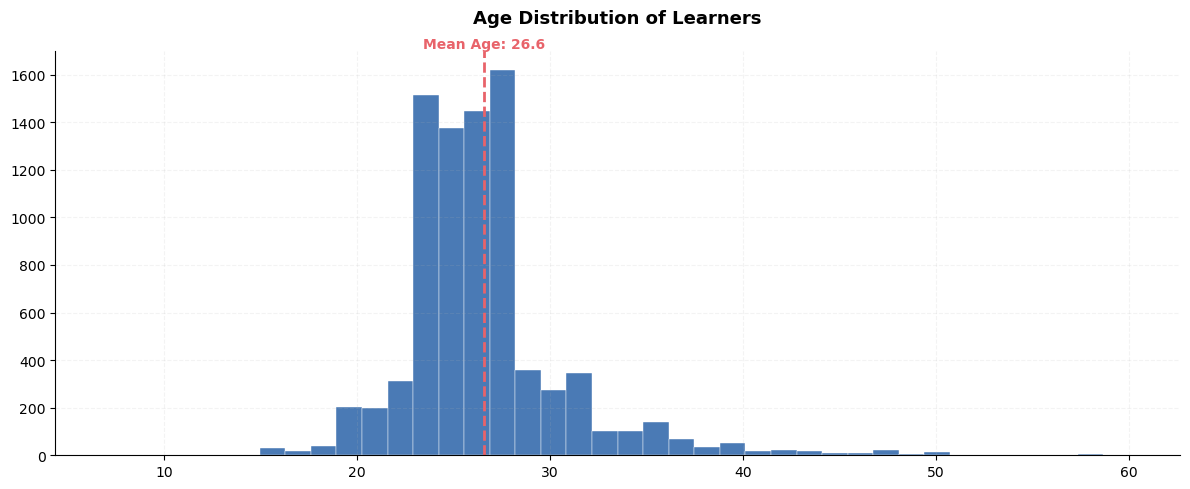

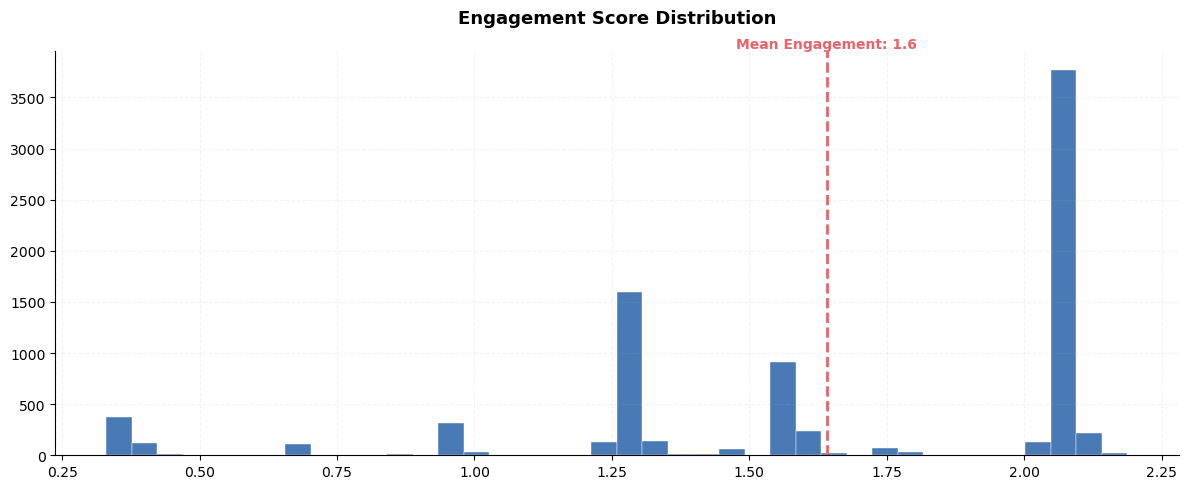

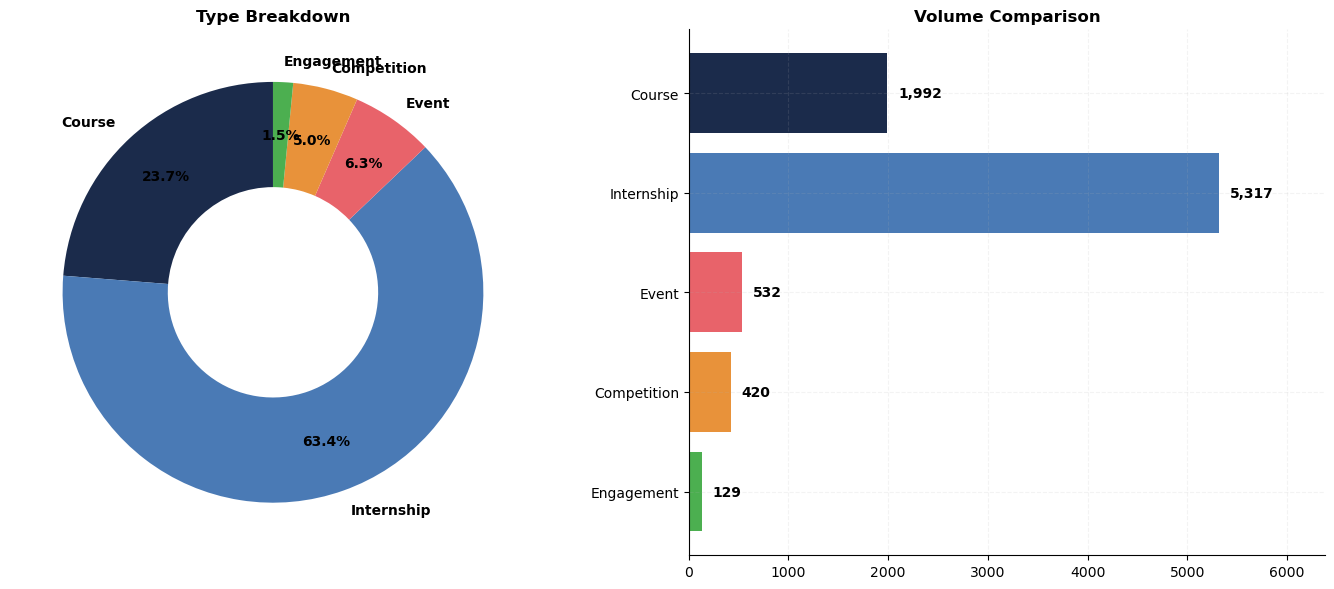

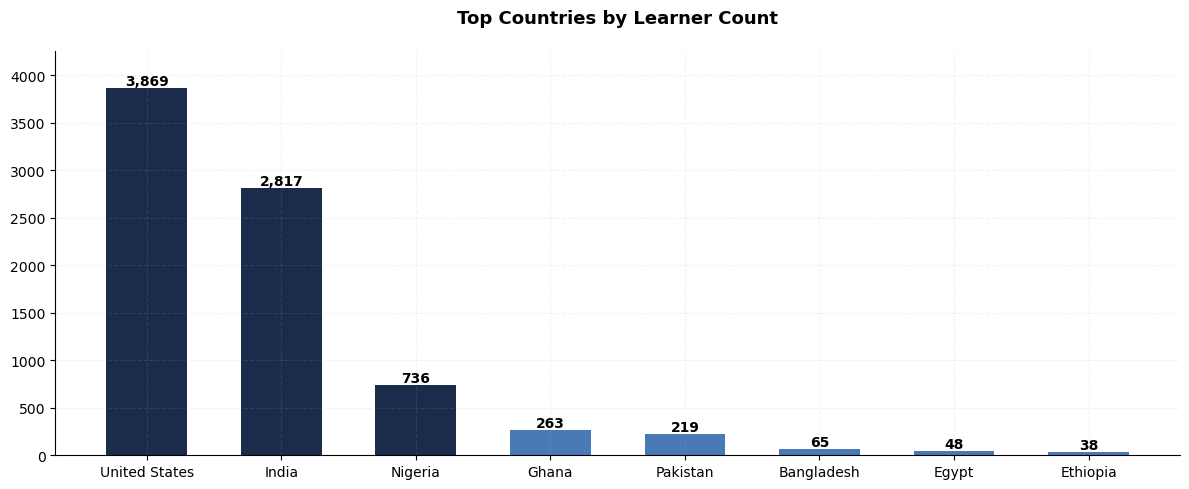

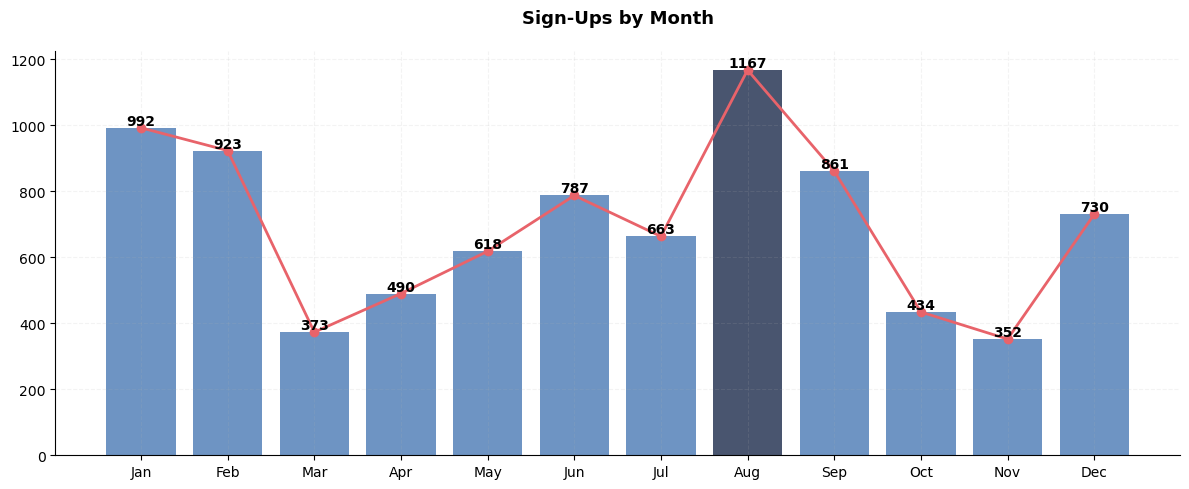

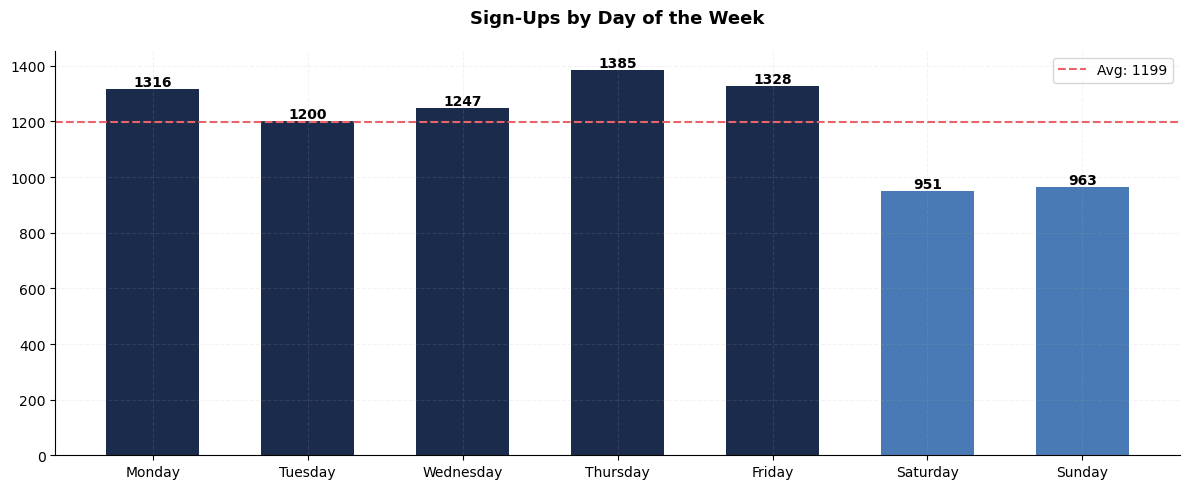

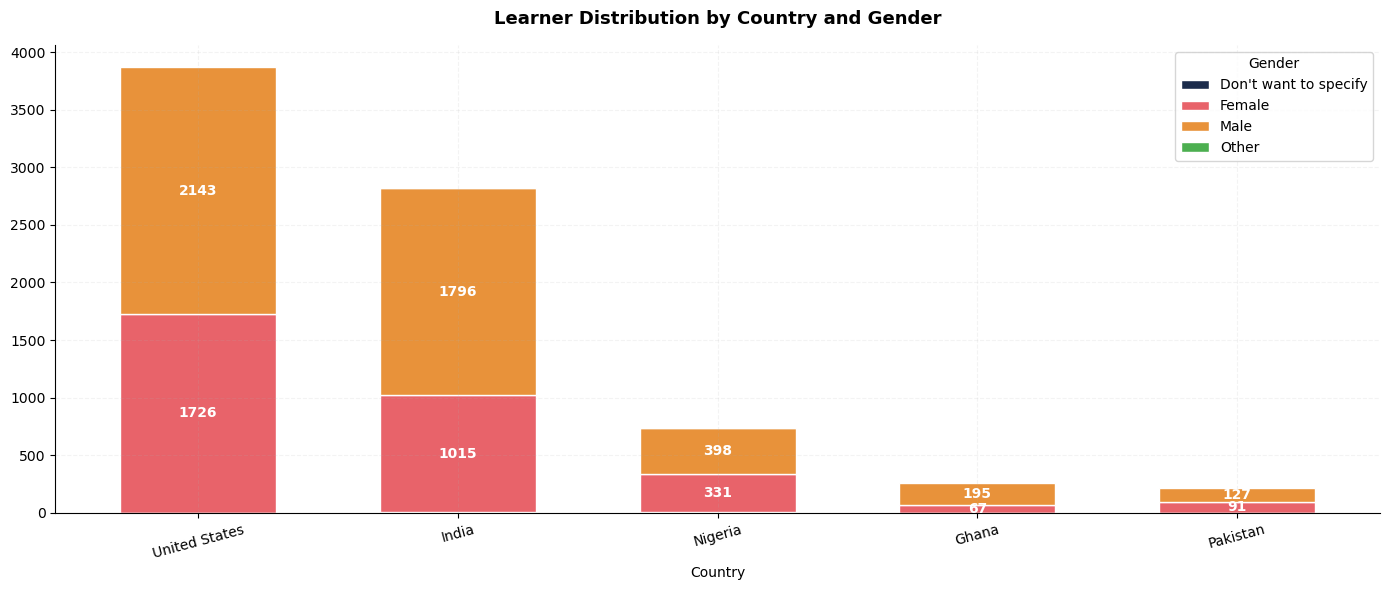

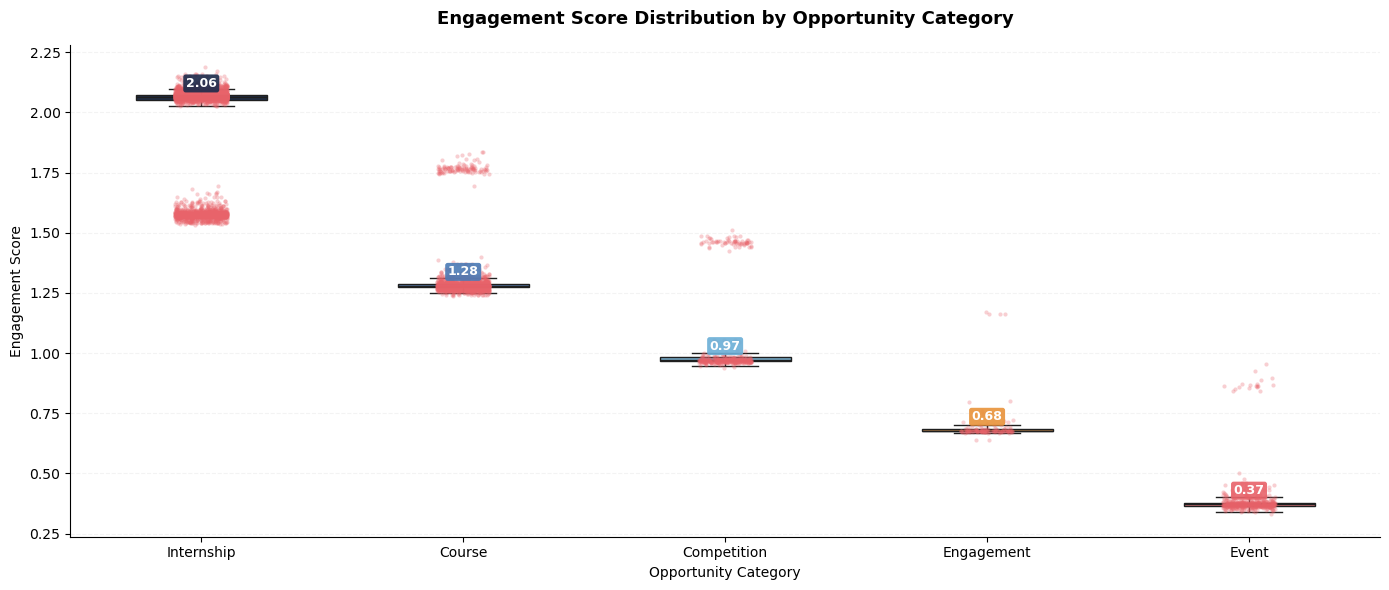

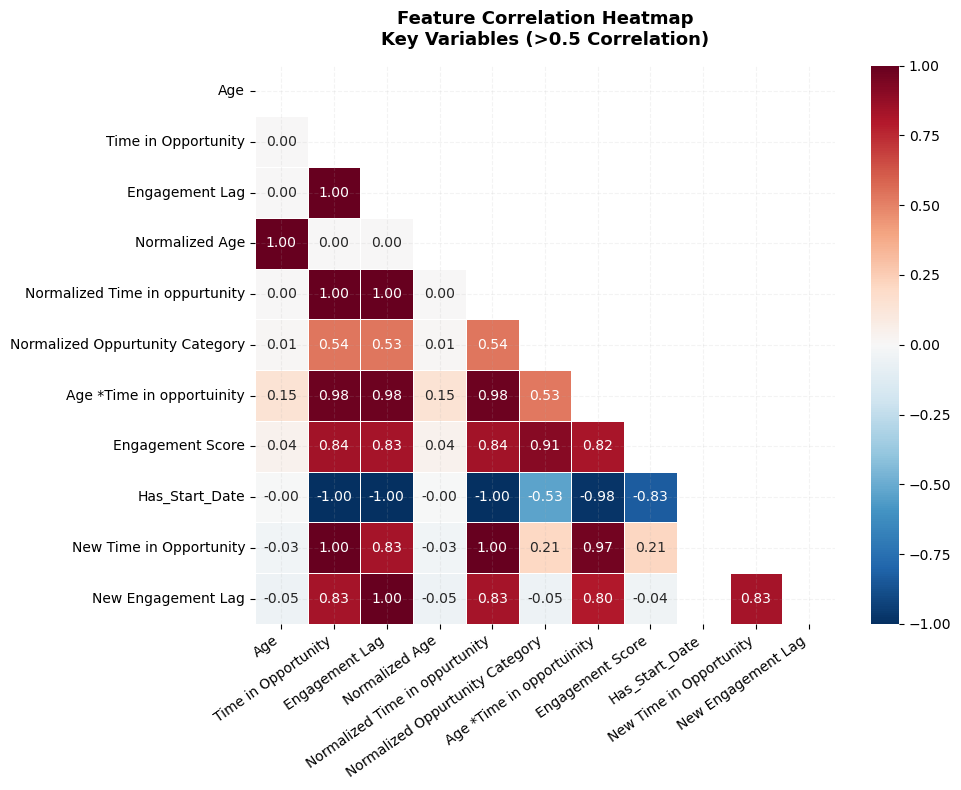


Full analysis complete. New Time and Lag metrics have been used.


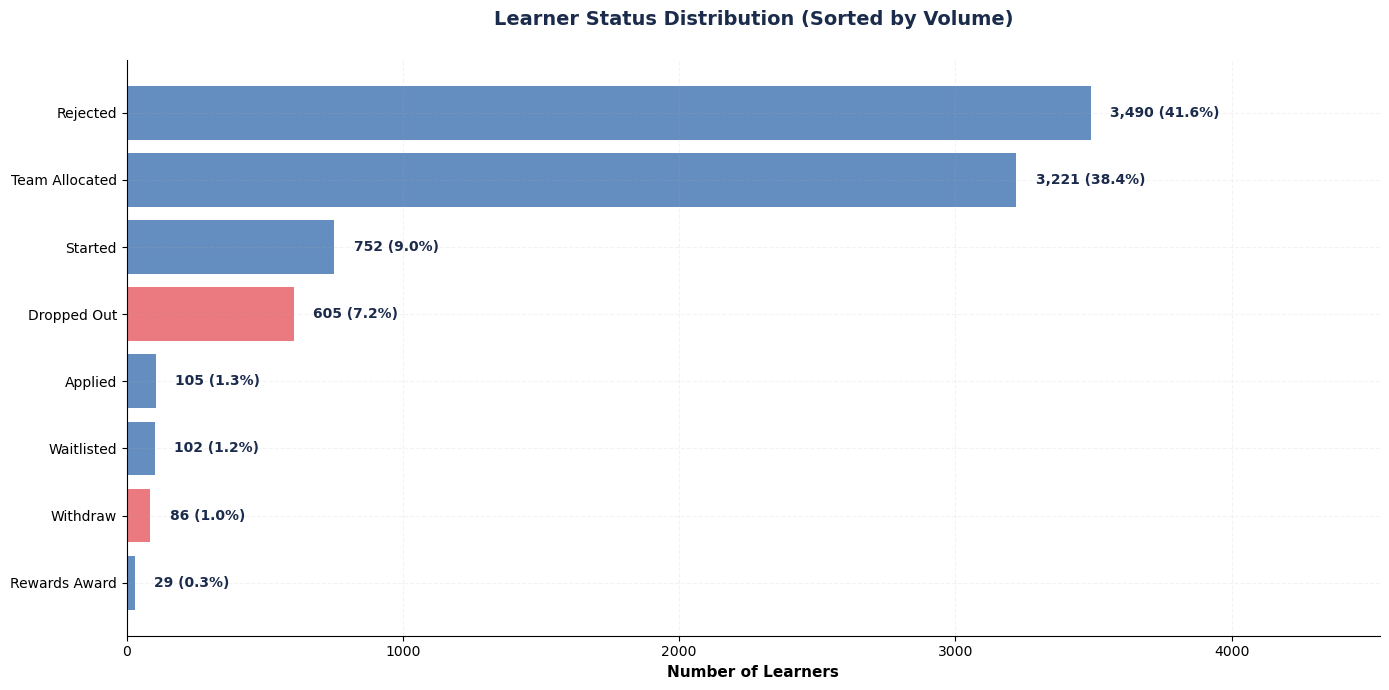

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# 1. LOAD & PREPROCESS DATA
# ─────────────────────────────────────────────────────────
df = pd.read_excel(r"C:\Users\EMMAN\Downloads\SLU Opportunity Wise Data.xlsx")

# Convert date columns to datetime
date_cols = ['Learner SignUp DateTime', 'Opportunity Start Date', 'Opportunity End Date', 'Apply Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Recalculate Time and Lag (Converting Timedeltas to numeric Days)
df['New Time in Opportunity'] = (df['Opportunity End Date'] - df['Opportunity Start Date']).abs().dt.days
df['New Engagement Lag'] = (df['Apply Date'] - df['Opportunity Start Date']).dt.days

# Define column mapping for consistency - Pointing all logic to the NEW fields
COL = {
    'age':               'Age',
    'engagement_score':  'Engagement Score',
    'category':          'Opportunity Category',
    'country':           'Country',
    'signup_month':      'Learner SignUp Month',
    'signup_day':        'Learner SignUp Day',
    'gender':            'Gender',
    'time_opp':          'New Time in Opportunity',  # Corrected to use recalculated field
    'eng_lag':           'New Engagement Lag'         # Corrected to use recalculated field
}

# ─────────────────────────────────────────────────────────
# 2. COLOURS & THEME SETTINGS
# ─────────────────────────────────────────────────────────
DARK_NAVY  = '#1B2B4B'
STEEL_BLUE = '#4A7AB5'
LIGHT_BLUE = '#6AAED6'
SALMON     = '#E8636A'
ORANGE     = '#E8923A'
GREEN      = '#4CAF50'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':         True,
    'grid.alpha':        0.15,
    'grid.linestyle':    '--',
})
# ═══════════════════════════════════════════════════════════
# SECTION 1A — Age Distribution
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
age_data = df[COL['age']].dropna()
mean_age = age_data.mean()

ax.hist(age_data, bins=40, color=STEEL_BLUE, edgecolor='white', linewidth=0.3)
ax.axvline(mean_age, color=SALMON, linestyle='--', linewidth=2)
ax.text(mean_age, ax.get_ylim()[1], f'Mean Age: {mean_age:.1f}', 
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=SALMON)

ax.set_title('Age Distribution of Learners', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('section1a_age_distribution.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 1B — Engagement Score Distribution
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
eng_data = df[COL['engagement_score']].dropna()
mean_eng = eng_data.mean()

ax.hist(eng_data, bins=40, color=STEEL_BLUE, edgecolor='white', linewidth=0.3)
ax.axvline(mean_eng, color=SALMON, linestyle='--', linewidth=2)
ax.text(mean_eng, ax.get_ylim()[1], f'Mean Engagement: {mean_eng:.1f}', 
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=SALMON)

ax.set_title('Engagement Score Distribution', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('section1b_engagement_distribution.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 2A — Opportunity Category Breakdown
# ═══════════════════════════════════════════════════════════
cat_order = ['Course', 'Internship', 'Event', 'Competition', 'Engagement']
cat_counts = df[COL['category']].value_counts().reindex(cat_order, fill_value=0)
cat_colors = [DARK_NAVY, STEEL_BLUE, SALMON, ORANGE, GREEN]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(cat_counts, labels=cat_order, autopct='%1.1f%%', colors=cat_colors, 
        startangle=90, wedgeprops=dict(width=0.5), pctdistance=0.75,
        textprops={'fontweight': 'bold'})
ax1.set_title('Type Breakdown', fontsize=12, fontweight='bold')

bars = ax2.barh(cat_order[::-1], cat_counts[cat_order[::-1]], color=cat_colors[::-1])
for bar in bars:
    width = bar.get_width()
    ax2.text(width + (cat_counts.max()*0.02), bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', va='center', ha='left', fontweight='bold')

ax2.set_title('Volume Comparison', fontsize=12, fontweight='bold')
ax2.set_xlim(0, cat_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('section2a_category_breakdown.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 2B — Top Countries
# ═══════════════════════════════════════════════════════════
country_counts = df[COL['country']].value_counts().head(8)
fig, ax = plt.subplots(figsize=(12, 5))
# Color Top 3 Navy, others Steel Blue
bar_colors = [DARK_NAVY if i < 3 else STEEL_BLUE for i in range(len(country_counts))]

bars = ax.bar(country_counts.index, country_counts.values, color=bar_colors, width=0.6)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', 
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Top Countries by Learner Count', fontsize=13, fontweight='bold', pad=20)
ax.set_ylim(0, country_counts.max() * 1.1)
plt.tight_layout()
plt.savefig('section2b_top_countries.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 3A — Sign-Ups by Month
# ═══════════════════════════════════════════════════════════
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df[COL['signup_month']].value_counts()

if str(monthly.index[0]).isdigit():
    monthly = monthly.reindex(range(1,13), fill_value=0)
    x_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
else:
    monthly = monthly.reindex(month_order, fill_value=0)
    x_labels = [m[:3] for m in month_order]

fig, ax = plt.subplots(figsize=(12, 5))
peak_val = monthly.max()
bar_colors = [DARK_NAVY if v == peak_val else STEEL_BLUE for v in monthly.values]

bars = ax.bar(x_labels, monthly.values, color=bar_colors, alpha=0.8)
ax.plot(x_labels, monthly.values, color=SALMON, marker='o', linewidth=2)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Sign-Ups by Month', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('section3a_signups_by_month.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 3B — Sign-Ups by Day of Week
# ═══════════════════════════════════════════════════════════
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df[COL['signup_day']].value_counts().reindex(day_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
# Weekdays Navy, Weekends Steel Blue
bar_colors = [DARK_NAVY if d not in ['Saturday', 'Sunday'] else STEEL_BLUE for d in day_order]

bars = ax.bar(day_order, day_counts.values, color=bar_colors, width=0.6)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

ax.axhline(day_counts.mean(), color=SALMON, linestyle='--', label=f'Avg: {day_counts.mean():.0f}')
ax.set_title('Sign-Ups by Day of the Week', fontsize=13, fontweight='bold', pad=20)
ax.legend()
plt.tight_layout()
plt.savefig('section3b_signups_by_day.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 4 — Demographic Breakdown by Country & Gender
# ═══════════════════════════════════════════════════════════
top_5_countries = df[COL['country']].value_counts().head(5).index
gender_df = df[df[COL['country']].isin(top_5_countries)]
gender_plot_data = (gender_df.groupby([COL['country'], COL['gender']]).size()
                    .unstack(fill_value=0).reindex(top_5_countries))

fig, ax = plt.subplots(figsize=(14, 6))
gender_plot_data.plot(kind='bar', stacked=True, ax=ax, color=[DARK_NAVY, SALMON, ORANGE, GREEN], width=0.6, edgecolor='white')

for p in ax.patches:
    h = p.get_height()
    if h > 50:
        ax.text(p.get_x()+p.get_width()/2, p.get_y()+h/2, f'{int(h)}', ha='center', va='center', color='white', fontweight='bold')

ax.set_title('Learner Distribution by Country and Gender', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('section4_country_gender.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 5 — Engagement Score by Category (Boxplot)
# ═══════════════════"C:\Users\EMMAN\Downloads\SLU Opportunity Wise Data.xlsx"════════════════════════════════════════
cat_order_eng = ['Internship', 'Course', 'Competition', 'Engagement', 'Event']
cat_palette = {'Internship': DARK_NAVY, 'Course': STEEL_BLUE, 'Competition': LIGHT_BLUE, 'Engagement': ORANGE, 'Event': SALMON}

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x=COL['category'], y=COL['engagement_score'], data=df, order=cat_order_eng, palette=cat_palette, width=0.5, fliersize=0, ax=ax)
sns.stripplot(x=COL['category'], y=COL['engagement_score'], data=df, order=cat_order_eng, size=3, color=SALMON, alpha=0.3, jitter=True, ax=ax)

for i, cat in enumerate(cat_order_eng):
    med = df[df[COL['category']] == cat][COL['engagement_score']].median()
    if not np.isnan(med):
        ax.text(i, med + 0.03, f'{med:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=cat_palette.get(cat, DARK_NAVY), alpha=0.9, edgecolor='none'))

ax.set_title('Engagement Score Distribution by Opportunity Category', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('section5_engagement_boxplot.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════
# SECTION 6 — Feature Correlation Heatmap
# ═══════════════════════════════════════════════════════════
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_keywords = ['Encoded', 'Status Code', 'Year', 'Month', 'Day']
cols_to_use = [c for c in numeric_cols if not any(k in c for k in exclude_keywords)]

# Explicitly ensure your new columns are analyzed
for c in [COL['time_opp'], COL['eng_lag']]:
    if c in df.columns and c not in cols_to_use:
        cols_to_use.append(c)

corr_matrix = df[cols_to_use].corr()
threshold = 0.5
logic_mask = (np.abs(corr_matrix) > threshold)
np.fill_diagonal(logic_mask.values, False)
keep_final = logic_mask.any(axis=0)
filtered_corr = corr_matrix.loc[keep_final, keep_final]

if not filtered_corr.empty:
    vis_mask = np.triu(np.ones_like(filtered_corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(filtered_corr, mask=vis_mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlation Heatmap\nKey Variables (>0.5 Correlation)', fontsize=13, fontweight='bold', pad=15)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig('section6_correlation_heatmap.png', dpi=150)
    plt.show()

print("\nFull analysis complete. New Time and Lag metrics have been used.")

# ═══════════════════════════════════════════════════════════
# SECTION 7 — Status Description Breakdown (Sorted by Count)
# ═══════════════════════════════════════════════════════════

# 1. Get counts and percentages sorted by frequency (descending)
status_counts = df['Status Description'].value_counts()
status_pct = (df['Status Description'].value_counts(normalize=True) * 100)

# 2. Map colors to the sorted index
# We recreate the color logic based on the status name in the new sorted order
status_colors = []
for status in status_counts.index:
    if status == 'Completed':
        status_colors.append(GREEN)      # Success
    elif status in ['Dropped Out', 'Withdraw']:
        status_colors.append(SALMON)     # Churn/Risk
    elif status == 'In Progress':
        status_colors.append(LIGHT_BLUE) # Active
    else:
        status_colors.append(STEEL_BLUE) # Pipeline

fig, ax = plt.subplots(figsize=(14, 7))

# 3. Create the horizontal bar chart
# We use [::-1] so the highest value appears at the top of the chart
bars = ax.barh(status_counts.index[::-1], status_counts.values[::-1], 
               color=status_colors[::-1], alpha=0.85)

# 4. Add numeric and percentage labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    # Align index for labels
    idx = len(status_counts) - 1 - i
    pct = status_pct.iloc[idx]
    
    ax.text(width + (status_counts.max() * 0.02), bar.get_y() + bar.get_height()/2,
            f'{int(width):,} ({pct:.1f}%)', 
            va='center', ha='left', fontweight='bold', color=DARK_NAVY)

# Styling and Annotations
ax.set_title('Learner Status Distribution (Sorted by Volume)', 
             fontsize=14, fontweight='bold', pad=25, color=DARK_NAVY)
ax.set_xlabel('Number of Learners', fontsize=11, fontweight='bold')
ax.set_xlim(0, status_counts.max() * 1.3) 

plt.tight_layout()
plt.savefig('section7_status_sorted.png', dpi=150)
plt.show()

Total Records: 8390
Total Churners: 691
Global Churn Rate: 8.24%
Model                | Accuracy   | Precision  | Recall     | F1-Score  
----------------------------------------------------------------------
Logistic Regression  | 0.9178     | 0.0000     | 0.0000     | 0.0000
Decision Tree        | 0.9207     | 0.5180     | 0.5217     | 0.5199
SVM                  | 0.9178     | 0.0000     | 0.0000     | 0.0000
Random Forest        | 0.9303     | 0.5913     | 0.4928     | 0.5375
Gradient Boosting    | 0.9422     | 0.8060     | 0.3913     | 0.5268


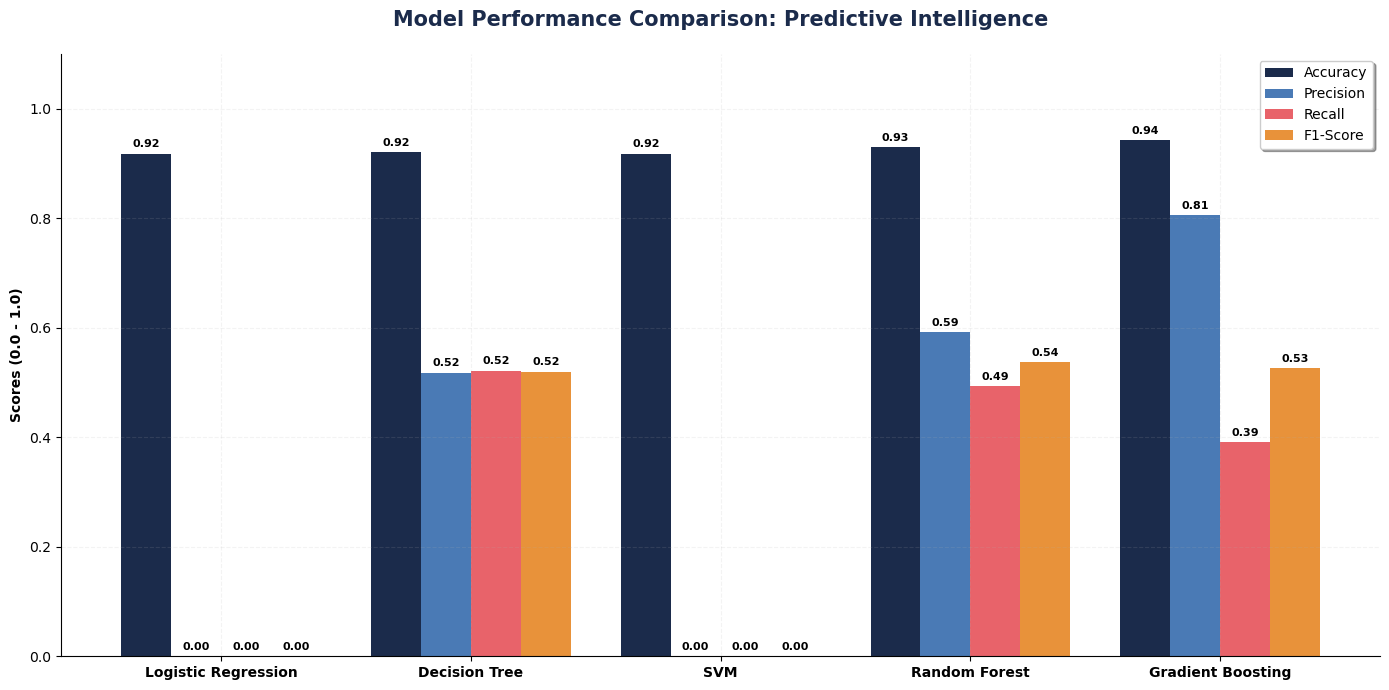

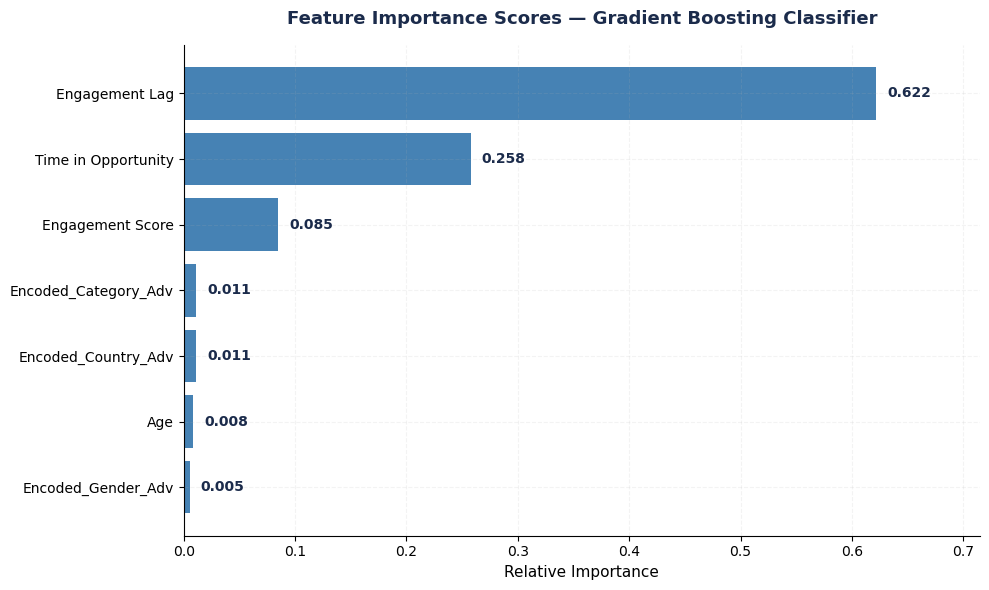

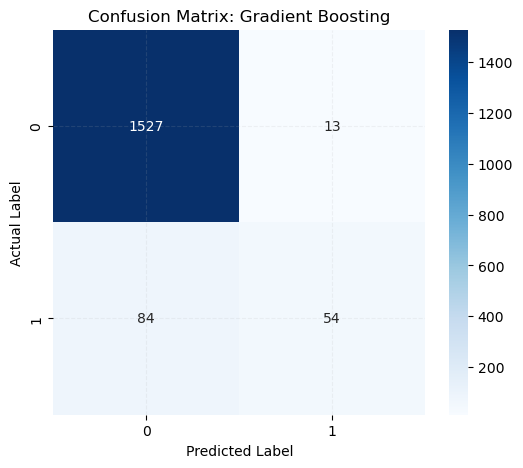

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. LOAD DATA
# Replace with your actual file path
df = pd.read_excel(r"C:\Users\EMMAN\Downloads\SLU Opportunity Wise Data.xlsx")

# 2. FEATURE ENGINEERING: TARGET VARIABLE
# Combining 'Dropped Out' and 'Withdraw' into a binary 'Is_Dropoff' label
dropoff_statuses = ['Dropped Out', 'Withdraw']
df['Is_Dropoff'] = df['Status Description'].apply(lambda x: 1 if x in dropoff_statuses else 0)

# 2. Global Churn Statistics
total_records = len(df)
total_churners = df['Is_Dropoff'].sum()
churn_rate = (total_churners / total_records) * 100

print(f"Total Records: {total_records}")
print(f"Total Churners: {total_churners}")
print(f"Global Churn Rate: {churn_rate:.2f}%")

# 3. DATA CLEANING & PREPROCESSING
# Selected features based on your report
features = [
    'Age', 'Engagement Score', 'Engagement Lag', 'Time in Opportunity',
    'Gender', 'Opportunity Category', 'Country'
]

# Handling missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Engagement Score'] = df['Engagement Score'].fillna(0)
df['Engagement Lag'] = df['Engagement Lag'].fillna(0)
df['Time in Opportunity'] = df['Time in Opportunity'].fillna(0)

# Categorical Encoding
le = LabelEncoder()
df['Encoded_Gender_Adv'] = le.fit_transform(df['Gender'].astype(str))
df['Encoded_Category_Adv'] = le.fit_transform(df['Opportunity Category'].astype(str))
df['Encoded_Country_Adv'] = le.fit_transform(df['Country'].astype(str))

# Final Feature List
X_features = [
    'Age', 'Engagement Score', 'Engagement Lag', 'Time in Opportunity',
    'Encoded_Gender_Adv', 'Encoded_Category_Adv', 'Encoded_Country_Adv'
]
X = df[X_features]
y = df['Is_Dropoff']

# 4. TRAIN/TEST SPLIT (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 5. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. MODEL EVALUATION LOOP
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

print(f"{'Model':<20} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 70)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = [acc, prec, rec, f1]
    print(f"{name:<20} | {acc:.4f}     | {prec:.4f}     | {rec:.4f}     | {f1:.4f}")

# 9. MODEL PERFORMANCE COMPARISON VISUALIZATION
# Prepare data for plotting
model_names = list(results.keys())
metrics = np.array(list(results.values())) # Acc, Prec, Rec, F1

x = np.arange(len(model_names))
width = 0.2  # width of the bars

fig, ax = plt.subplots(figsize=(14, 7))

# Create bars for each metric
rects1 = ax.bar(x - width*1.5, metrics[:, 0], width, label='Accuracy', color=DARK_NAVY)
rects2 = ax.bar(x - width/2,   metrics[:, 1], width, label='Precision', color=STEEL_BLUE)
rects3 = ax.bar(x + width/2,   metrics[:, 2], width, label='Recall', color=SALMON)
rects4 = ax.bar(x + width*1.5, metrics[:, 3], width, label='F1-Score', color=ORANGE)

# Add text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores (0.0 - 1.0)', fontweight='bold')
ax.set_title('Model Performance Comparison: Predictive Intelligence', 
             fontsize=15, fontweight='bold', pad=20, color=DARK_NAVY)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontweight='bold')
ax.set_ylim(0, 1.1) # Extra space for the legend
ax.legend(loc='upper right', frameon=True, shadow=True)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.show()

# 7. FEATURE IMPORTANCE (Gradient Boosting)
best_model = models["Gradient Boosting"]
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
# Define the plot and capture the bar objects
bars = plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')

# Add labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01,           # X position (slightly to the right of the bar)
             bar.get_y() + bar.get_height()/2, # Y position (center of the bar)
             f'{width:.3f}',         # The label (formatted to 3 decimal places)
             va='center',            # Vertical alignment
             fontweight='bold', 
             color=DARK_NAVY)        # Using your theme color

plt.yticks(range(len(indices)), [X_features[i] for i in indices])
plt.title('Feature Importance Scores — Gradient Boosting Classifier', 
          fontsize=13, fontweight='bold', pad=15, color=DARK_NAVY)
plt.xlabel('Relative Importance', fontsize=11)

# Extend x-axis slightly so labels don't get cut off
plt.xlim(0, max(importances) * 1.15)

plt.tight_layout()
plt.show()

# 8. CONFUSION MATRIX (Gradient Boosting)
y_pred_gb = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Gradient Boosting')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Total Records:     8390
Total Churners:    691
Global Churn Rate: 8.24%

--- Class Balance After SMOTE ---
Before → Churners: 553  | Non-Churners: 6,159
After  → Churners: 6,159 | Non-Churners: 6,159

Model                  | Accuracy   | Precision  | Recall     | F1-Score  
------------------------------------------------------------------------
Logistic Regression    | 0.7384     | 0.1777     | 0.6014     | 0.2744
Decision Tree          | 0.8933     | 0.3990     | 0.5870     | 0.4751
SVM                    | 0.6883     | 0.1640     | 0.6812     | 0.2644
Random Forest          | 0.9118     | 0.4706     | 0.5797     | 0.5195
Gradient Boosting      | 0.8689     | 0.3633     | 0.7899     | 0.4977


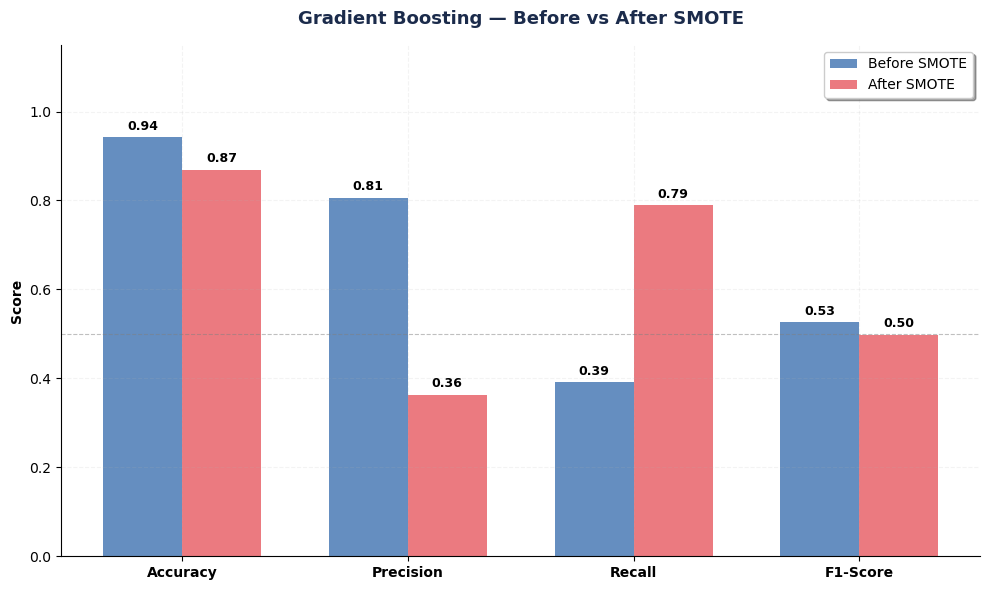

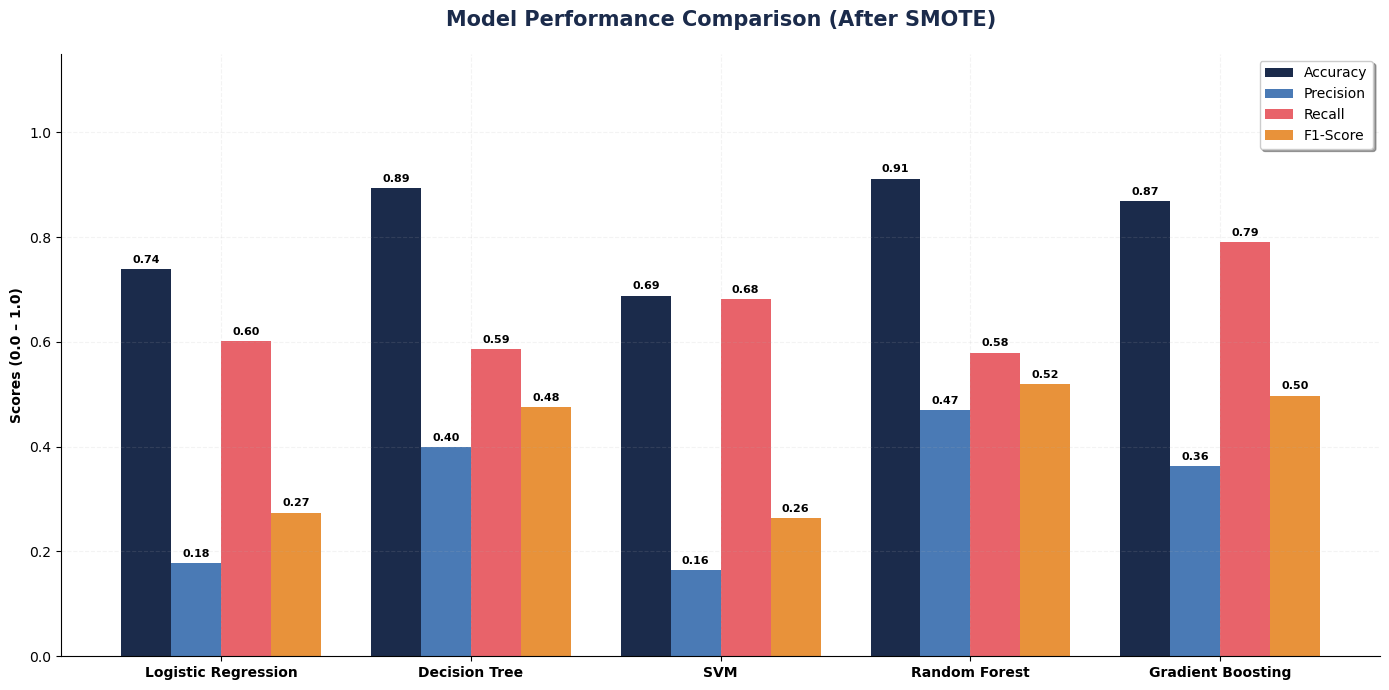

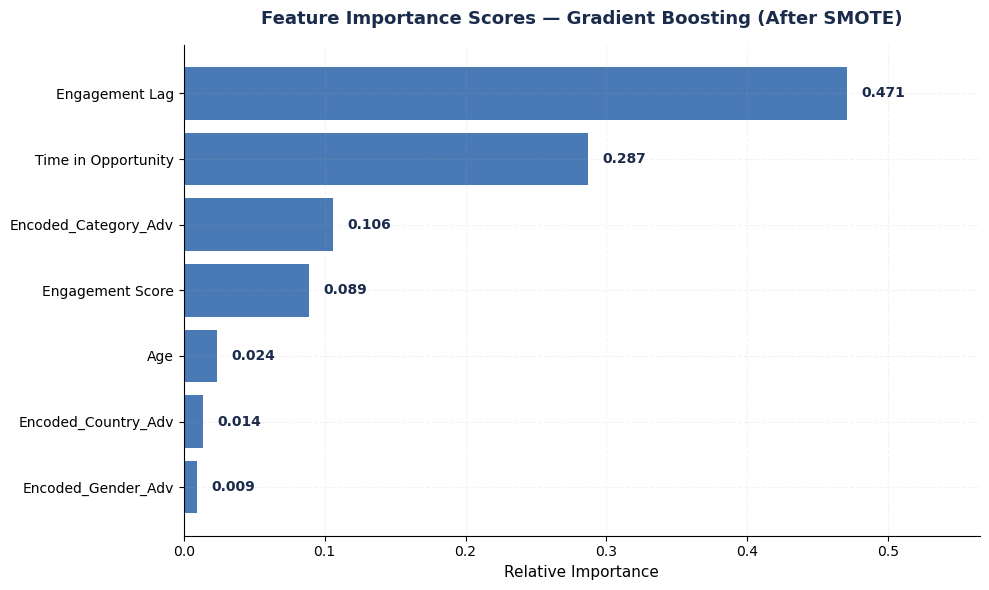

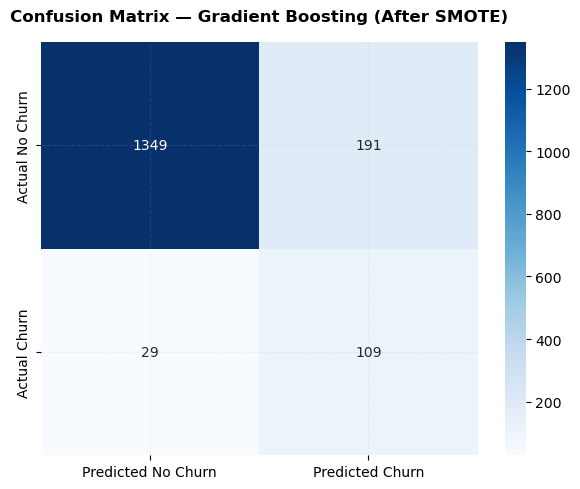


--- Threshold Tuning (Gradient Boosting After SMOTE) ---
Threshold    | Precision  | Recall     | F1        
------------------------------------------------
0.5          | 0.3633     | 0.7899     | 0.4977
0.4          | 0.3447     | 0.8043     | 0.4826
0.3          | 0.2935     | 0.8551     | 0.4370
0.2          | 0.1725     | 0.8986     | 0.2894

Done. Pick the threshold row where Recall meets your acceptable Precision floor.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE  # NEW

# ─────────────────────────────────────────────────────────
# COLOUR THEME
# ─────────────────────────────────────────────────────────
DARK_NAVY  = '#1B2B4B'
STEEL_BLUE = '#4A7AB5'
LIGHT_BLUE = '#6AAED6'
SALMON     = '#E8636A'
ORANGE     = '#E8923A'
GREEN      = '#4CAF50'

# ─────────────────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────────────────
df = pd.read_excel(r"C:\Users\EMMAN\Downloads\SLU Opportunity Wise Data.xlsx")

# ─────────────────────────────────────────────────────────
# 2. TARGET VARIABLE
# ─────────────────────────────────────────────────────────
dropoff_statuses = ['Dropped Out', 'Withdraw']
df['Is_Dropoff'] = df['Status Description'].apply(lambda x: 1 if x in dropoff_statuses else 0)

total_records  = len(df)
total_churners = df['Is_Dropoff'].sum()
churn_rate     = (total_churners / total_records) * 100

print(f"Total Records:     {total_records}")
print(f"Total Churners:    {total_churners}")
print(f"Global Churn Rate: {churn_rate:.2f}%")

# ─────────────────────────────────────────────────────────
# 3. CLEANING & PREPROCESSING
# ─────────────────────────────────────────────────────────
df['Age']                 = df['Age'].fillna(df['Age'].mean())
df['Engagement Score']    = df['Engagement Score'].fillna(0)
df['Engagement Lag']      = df['Engagement Lag'].fillna(0)
df['Time in Opportunity'] = df['Time in Opportunity'].fillna(0)

le = LabelEncoder()
df['Encoded_Gender_Adv']   = le.fit_transform(df['Gender'].astype(str))
df['Encoded_Category_Adv'] = le.fit_transform(df['Opportunity Category'].astype(str))
df['Encoded_Country_Adv']  = le.fit_transform(df['Country'].astype(str))

X_features = [
    'Age', 'Engagement Score', 'Engagement Lag', 'Time in Opportunity',
    'Encoded_Gender_Adv', 'Encoded_Category_Adv', 'Encoded_Country_Adv'
]
X = df[X_features]
y = df['Is_Dropoff']

# ─────────────────────────────────────────────────────────
# 4. TRAIN/TEST SPLIT (80/20 Stratified)
# ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ─────────────────────────────────────────────────────────
# 5. FEATURE SCALING
# ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # Test data is NEVER resampled

# ─────────────────────────────────────────────────────────
# 5B. SMOTE — Balance the training set only
# ─────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n--- Class Balance After SMOTE ---")
print(f"Before → Churners: {y_train.sum():,}  | Non-Churners: {(y_train == 0).sum():,}")
print(f"After  → Churners: {y_train_resampled.sum():,} | Non-Churners: {(y_train_resampled == 0).sum():,}")

# ─────────────────────────────────────────────────────────
# 6. MODEL TRAINING & EVALUATION
# ─────────────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "SVM":                 SVC(probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results        = {}  # After SMOTE scores
results_before = {}  # Before SMOTE scores (for comparison chart)

print(f"\n{'Model':<22} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 72)

for name, model in models.items():
    # --- BEFORE SMOTE (original imbalanced training data) ---
    model.fit(X_train_scaled, y_train)
    y_pred_before = model.predict(X_test_scaled)
    results_before[name] = [
        accuracy_score(y_test, y_pred_before),
        precision_score(y_test, y_pred_before, zero_division=0),
        recall_score(y_test, y_pred_before, zero_division=0),
        f1_score(y_test, y_pred_before, zero_division=0)
    ]

    # --- AFTER SMOTE (resampled training data) ---
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    results[name] = [acc, prec, rec, f1]
    print(f"{name:<22} | {acc:.4f}     | {prec:.4f}     | {rec:.4f}     | {f1:.4f}")

# ─────────────────────────────────────────────────────────
# 7. BEFORE vs AFTER SMOTE COMPARISON (Gradient Boosting)
# ─────────────────────────────────────────────────────────
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
before_vals    = results_before["Gradient Boosting"]
after_vals     = results["Gradient Boosting"]

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, before_vals, width, label='Before SMOTE', color=STEEL_BLUE, alpha=0.85)
bars2 = ax.bar(x + width/2, after_vals,  width, label='After SMOTE',  color=SALMON,     alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Gradient Boosting — Before vs After SMOTE',
             fontsize=13, fontweight='bold', pad=15, color=DARK_NAVY)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontweight='bold')
ax.legend(frameon=True, shadow=True)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# 8. MODEL PERFORMANCE COMPARISON (After SMOTE — All Models)
# ─────────────────────────────────────────────────────────
model_names = list(results.keys())
metrics     = np.array(list(results.values()))

x     = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width*1.5, metrics[:, 0], width, label='Accuracy',  color=DARK_NAVY)
rects2 = ax.bar(x - width/2,   metrics[:, 1], width, label='Precision', color=STEEL_BLUE)
rects3 = ax.bar(x + width/2,   metrics[:, 2], width, label='Recall',    color=SALMON)
rects4 = ax.bar(x + width*1.5, metrics[:, 3], width, label='F1-Score',  color=ORANGE)

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

autolabel(rects1); autolabel(rects2); autolabel(rects3); autolabel(rects4)

ax.set_ylabel('Scores (0.0 – 1.0)', fontweight='bold')
ax.set_title('Model Performance Comparison (After SMOTE)',
             fontsize=15, fontweight='bold', pad=20, color=DARK_NAVY)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# 9. FEATURE IMPORTANCE — Gradient Boosting (After SMOTE)
# ─────────────────────────────────────────────────────────
best_model  = models["Gradient Boosting"]
importances = best_model.feature_importances_
indices     = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(indices)), importances[indices], color=STEEL_BLUE, align='center')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center', fontweight='bold', color=DARK_NAVY)

ax.set_yticks(range(len(indices)))
ax.set_yticklabels([X_features[i] for i in indices])
ax.set_title('Feature Importance Scores — Gradient Boosting (After SMOTE)',
             fontsize=13, fontweight='bold', pad=15, color=DARK_NAVY)
ax.set_xlabel('Relative Importance', fontsize=11)
ax.set_xlim(0, max(importances) * 1.2)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# 10. CONFUSION MATRIX — Gradient Boosting (After SMOTE)
# ─────────────────────────────────────────────────────────
y_pred_gb = best_model.predict(X_test_scaled)
cm        = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn',    'Actual Churn'])
ax.set_title('Confusion Matrix — Gradient Boosting (After SMOTE)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# 11. THRESHOLD TUNING — Push Recall Further
# ─────────────────────────────────────────────────────────
print("\n--- Threshold Tuning (Gradient Boosting After SMOTE) ---")
print(f"{'Threshold':<12} | {'Precision':<10} | {'Recall':<10} | {'F1':<10}")
print("-" * 48)

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_prob >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:<12} | {p:.4f}     | {r:.4f}     | {f:.4f}")

print("\nDone. Pick the threshold row where Recall meets your acceptable Precision floor.")

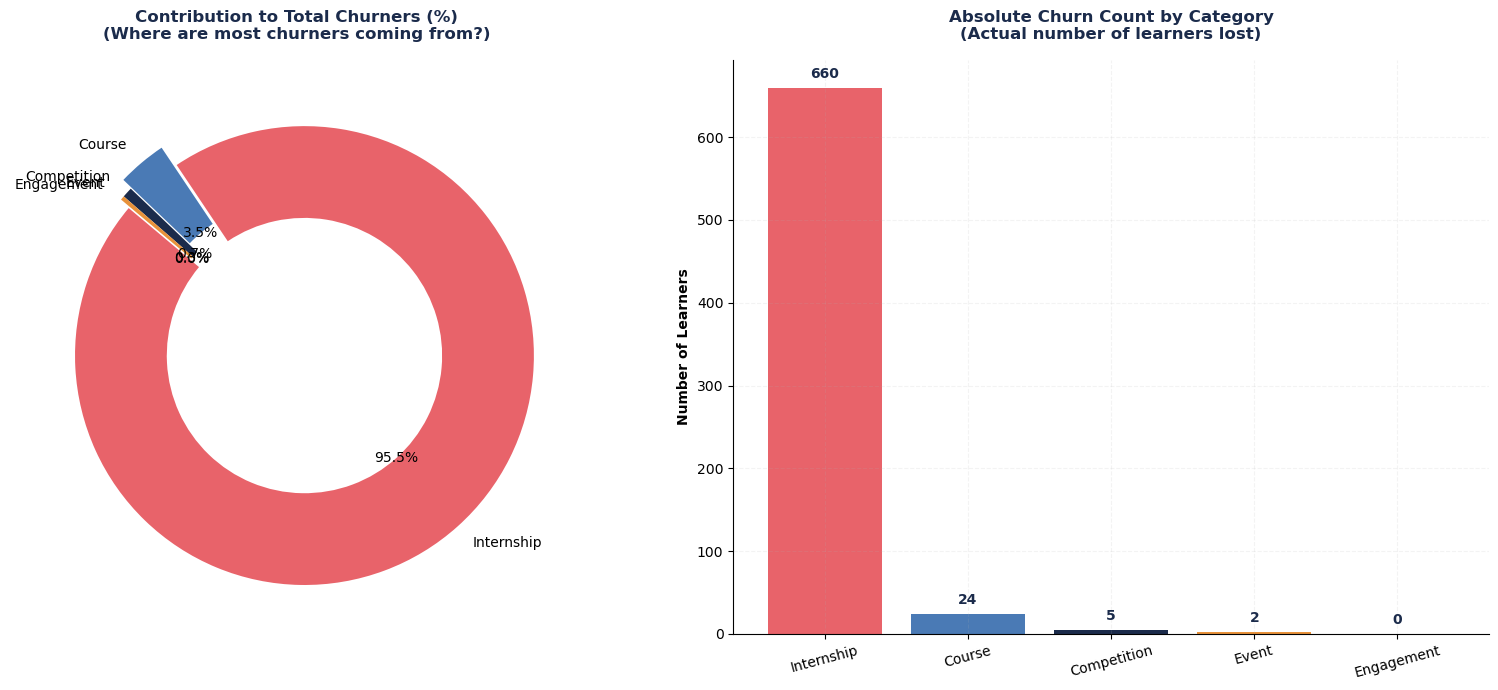

In [11]:
# 1. Aggregation (Creating the dataset)
cat_stats = df.groupby(COL['category']).agg(
    Churn_Count=('Is_Dropoff', 'sum')
).reset_index()

total_global_churn = cat_stats['Churn_Count'].sum()
cat_stats['Churn_Share'] = (cat_stats['Churn_Count'] / total_global_churn) * 100

# 2. Sorting (Ensures the biggest categories are first in both charts)
cat_stats = cat_stats.sort_values('Churn_Share', ascending=False)

# 3. Dynamic Explode & Colors
num_cats = len(cat_stats)
dynamic_explode = tuple([0.05 if i < 2 else 0.0 for i in range(num_cats)])

# Category Palette Mapping
category_palette = {
    'Course': STEEL_BLUE, 'Internship': SALMON, 'Event': ORANGE, 
    'Competition': DARK_NAVY, 'Engagement': GREEN
}
pie_colors = [category_palette.get(cat, DARK_NAVY) for cat in cat_stats[COL['category']]]

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Pie Chart
ax1.pie(cat_stats['Churn_Share'], 
        labels=cat_stats[COL['category']], 
        colors=pie_colors, 
        autopct='%1.1f%%', 
        startangle=140, 
        explode=dynamic_explode,
        wedgeprops=dict(width=0.4))
ax1.set_title('Contribution to Total Churners (%)\n(Where are most churners coming from?)', 
             fontsize=12, fontweight='bold', pad=15, color=DARK_NAVY)

# RIGHT: Bar Chart — NOW WITH MATCHING PIE COLORS
# Passing pie_colors here ensures each bar matches its pie slice color
bars2 = ax2.bar(cat_stats[COL['category']], cat_stats['Churn_Count'], color=pie_colors)

ax2.set_title('Absolute Churn Count by Category\n(Actual number of learners lost)', 
             fontsize=12, fontweight='bold', pad=15, color=DARK_NAVY)
ax2.set_ylabel('Number of Learners', fontweight='bold')

# Add Labels on top of bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold', color=DARK_NAVY)

# Clean up x-axis labels
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('figure4_sync_colors.png', dpi=150)
plt.show()